In [1]:
# Celula 1: prepara o ambiente de trabalho para toda a analise.
# - pandas/numpy: manipulacao de dados
# - matplotlib: graficos
# - scikit-learn: validacao cruzada e metricas
# - xgboost: modelo de classificacao
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    r2_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
    log_loss,
    ConfusionMatrixDisplay,
)

# Instala automaticamente o xgboost apenas se ele nao estiver disponivel.
try:
    from xgboost import XGBClassifier
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    from xgboost import XGBClassifier

# Instala automaticamente o optuna apenas se ele nao estiver disponivel.
try:
    import optuna
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna

# Instala automaticamente o optuna-dashboard apenas se ele nao estiver disponivel.
try:
    import optuna_dashboard
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna-dashboard", "-q"])
    import optuna_dashboard

# Mostra todas as colunas ao inspecionar DataFrames.
pd.set_option("display.max_columns", None)
print("Bibliotecas carregadas com sucesso.")

c:\Users\otavi\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bibliotecas carregadas com sucesso.


In [2]:
# Celula 2: leitura da base e preparo das variaveis de entrada.
# Objetivo: montar X (features) e y (alvo) sem vazamento de informacao.
csv_path = Path(r"C:\Users\otavi\OneDrive\Desktop\last-mile-tcc\backend\tabela_final\part-00000-bc8041e1-56a7-4223-b839-8474dfbae85d-c000.csv")
df = pd.read_csv(csv_path)

# Variavel alvo: 1 = entregue no prazo, 0 = atraso.
target_col = "delivered_on_time"
if target_col not in df.columns:
    raise ValueError(f"A coluna alvo '{target_col}' nao foi encontrada no CSV.")

# Remove colunas que representam informacao conhecida apenas apos a entrega.
# Se usadas no treino, o modelo "cola" e as metricas ficam irreais.
leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]
leakage_cols = [c for c in leakage_candidates if c in df.columns]

# Separa previsores e alvo.
feature_cols = [c for c in df.columns if c != target_col and c not in leakage_cols]
X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()

# Converte colunas nao numericas para numerico e trata faltantes com mediana.
for col in X.select_dtypes(exclude=[np.number]).columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
X = X.dropna(axis=1, how="all")

# Divide em treino/teste com split temporal (Passado treina, Futuro testa).
# Treino: ate Junho de 2018 | Teste: Julho de 2018 em diante.
split_date = pd.to_datetime("2018-07-01", utc=True)
date_col = pd.to_datetime(df['order_delivered_carrier_date'], utc=True)

# Remover colunas (clima e vazamento de dados)
colunas_remover = [
    # Vazamento de dados / Pos-compra (ocorrem apos aprovacao ou derivam do tempo de entrega)
    'order_delivered_customer_date', 
    'order_delivered_carrier_date',
    'review_score', 
    # 'delivered_on_time', # Vamos manter esta no df principal apenas para analises descritivas, nao passaremos ela para 'X'.
    'approval_time_hours', 
    'handling_time_hours', 
    'shipping_delay_hours',
    
    # Variaveis climaticas (Vendedor)
    'seller_total_rainfall_period_mm',
    'seller_max_rain_intensity_mm_h',
    'seller_max_wind_gust_period_ms',
    'seller_interval_code',
    'seller_rain_class_code',
    'seller_wind_class_code',
    'seller_accumulated_rainfall_3_days_mm',
    'seller_is_heavy_rain',
    'seller_is_strong_wind',
    
    # Variaveis climaticas (Cliente)
    'customer_total_rainfall_period_mm',
    'customer_max_rain_intensity_mm_h',
    'customer_max_wind_gust_period_ms',
    'customer_interval_code',
    'customer_rain_class_code',
    'customer_wind_class_code',
    'customer_accumulated_rainfall_3_days_mm',
    'customer_is_heavy_rain',
    'customer_is_strong_wind',

    'seller_meso_metropolitana_de_sao_paulo',
    'seller_meso_araraquara',
    'seller_meso_piracicaba',
    'seller_meso_ribeirao_preto',
    'seller_meso_sao_jose_do_rio_preto',
    'seller_meso_campinas',
    'seller_meso_vale_do_paraiba_paulista',
    'seller_meso_macro_metropolitana_paulista',
    'seller_meso_bauru',
    'seller_meso_presidente_prudente',
    'seller_meso_marilia',
    'seller_meso_assis',
    'seller_meso_aracatuba',
    'seller_meso_litoral_sul_paulista',
    'seller_meso_itapetininga',
    'customer_meso_metropolitana_de_sao_paulo',
    'customer_meso_piracicaba',
    'customer_meso_campinas',
    'customer_meso_vale_do_paraiba_paulista',
    'customer_meso_ribeirao_preto',
    'customer_meso_sao_jose_do_rio_preto',
    'customer_meso_macro_metropolitana_paulista',
    'customer_meso_bauru','customer_meso_araraquara',
    'customer_meso_presidente_prudente',
    'customer_meso_marilia',
    'customer_meso_assis',
    'customer_meso_aracatuba',
    'customer_meso_itapetininga',
    'customer_meso_litoral_sul_paulista'
]

X = X.drop(columns=colunas_remover, errors='ignore') 

# X.info()

train_mask = date_col < split_date
test_mask = date_col >= split_date

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()

# Calcula peso da classe atraso (classe 0) para forcar o modelo a olhar mais para atrasos.
w0 = float((y_train == 1).sum() / max((y_train == 0).sum(), 1))

total_linhas = len(df)
qtd_treino = len(X_train)
qtd_teste = len(X_test)


print(f"Total de registros: Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]} | Peso: {w0:.2f}\n")
print(f"Treino (ate Jun/2018): {qtd_treino:,} ({qtd_treino/total_linhas:.2%})")
print(f" - Atrasos no Treino: {y_train[y_train == 0].shape[0]} ({(y_train == 0).mean():.2%} do treino)\n")
print(f"Teste (Jul/2018 em diante): {qtd_teste:,} ({qtd_teste/total_linhas:.2%})")
print(f" - Atrasos no Teste: {y_test[y_test == 0].shape[0]} ({(y_test == 0).mean():.2%} do teste)\n")

Total de registros: Linhas: 33,820 | Colunas: 71 | Peso: 19.14

Treino (ate Jun/2018): 28,706 (84.88%)
 - Atrasos no Treino: 1425 (4.96% do treino)

Teste (Jul/2018 em diante): 5,114 (15.12%)
 - Atrasos no Teste: 613 (11.99% do teste)



In [3]:
# Celula 3: define funcoes e configuracoes da busca de hiperparametros.
# A avaliacao desta analise trata "atraso" (classe 0) como classe positiva.
def metricas_atraso(y_true_original, y_pred_atraso, y_proba_atraso):
    y_true_atraso = (y_true_original == 0).astype(int)
    return {
        "accuracy_atraso": accuracy_score(y_true_atraso, y_pred_atraso),
        "precision_atraso": precision_score(y_true_atraso, y_pred_atraso, zero_division=0),
        "recall_atraso": recall_score(y_true_atraso, y_pred_atraso, zero_division=0),
        "f1_atraso": f1_score(y_true_atraso, y_pred_atraso, zero_division=0),
        "f2_atraso": fbeta_score(y_true_atraso, y_pred_atraso, beta=2, zero_division=0),
        "roc_auc_atraso": roc_auc_score(y_true_atraso, y_proba_atraso),
        "pr_auc_atraso": average_precision_score(y_true_atraso, y_proba_atraso),
        "r2_atraso": r2_score(y_true_atraso, y_proba_atraso),
        "balanced_accuracy_atraso": balanced_accuracy_score(y_true_atraso, y_pred_atraso),
        "mcc_atraso": matthews_corrcoef(y_true_atraso, y_pred_atraso),
        "brier_score_atraso": brier_score_loss(y_true_atraso, y_proba_atraso),
        "log_loss_atraso": log_loss(y_true_atraso, y_proba_atraso),
    }


def metricas_gerais(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "R2": r2_score(y_true, y_proba),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Brier Score": brier_score_loss(y_true, y_proba),
        "Log Loss": log_loss(y_true, y_proba),
    }

# Configuracao do Optuna para busca de hiperparametros.
n_trials = 25
study_seed = 42
cv_tune = TimeSeriesSplit(n_splits=3)
threshold_grid_tune = np.arange(0.10, 0.91, 0.02)

# Vetor binario: 1 = atraso, 0 = nao atraso.
y_train_atraso = (y_train == 0).astype(int).values

print("Preparacao da busca de hiperparametros concluida.")

Preparacao da busca de hiperparametros concluida.


In [4]:
# Celula 4: busca de hiperparametros com Optuna + validacao cruzada.
# Criterio de selecao: maior F2 para atraso, com pequeno desempate por recall.
optuna_db_path = Path("optuna_xgb_temporal.db").resolve()
study_storage = f"sqlite:///{optuna_db_path.as_posix()}"
study_name = "xgb_temporal_split"

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 250, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),
        "subsample": trial.suggest_float("subsample", 0.7, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.9),
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 9, step=2),
        "gamma": trial.suggest_float("gamma", 0.0, 0.2),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 0.3),
        "reg_lambda": trial.suggest_float("reg_lambda", 2.0, 5.0),
    }

    oof_proba_atraso = np.zeros(len(y_train), dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(cv_tune.split(X_train, y_train), start=1):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr = y_train.iloc[tr_idx]
        sw_tr = np.where(y_tr.values == 0, w0, 1.0)

        mdl = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=1000 + trial.number * 10 + fold,
            n_jobs=-1,
            **params,
        )
        mdl.fit(X_tr, y_tr, sample_weight=sw_tr)

        # Probabilidade de atraso = 1 - probabilidade da classe "no prazo".
        proba_atraso_va = 1.0 - mdl.predict_proba(X_va)[:, 1]
        oof_proba_atraso[va_idx] = proba_atraso_va

    # Para cada conjunto de parametros, busca o melhor limiar de decisao.
    best_thr_i = 0.50
    best_f2_i = -1.0
    best_recall_i = -1.0
    best_precision_i = -1.0

    for thr in threshold_grid_tune:
        pred_atraso = (oof_proba_atraso >= thr).astype(int)
        precision_i = precision_score(y_train_atraso, pred_atraso, zero_division=0)
        recall_i = recall_score(y_train_atraso, pred_atraso, zero_division=0)
        f2_i = fbeta_score(y_train_atraso, pred_atraso, beta=2, zero_division=0)

        if (f2_i > best_f2_i) or (np.isclose(f2_i, best_f2_i) and recall_i > best_recall_i):
            best_f2_i = float(f2_i)
            best_recall_i = float(recall_i)
            best_precision_i = float(precision_i)
            best_thr_i = float(thr)

    trial.set_user_attr("best_threshold", best_thr_i)
    trial.set_user_attr("cv_f2_atraso", best_f2_i)
    trial.set_user_attr("cv_recall_atraso", best_recall_i)
    trial.set_user_attr("cv_precision_atraso", best_precision_i)

    # Pequeno bonus para recall em caso de empate em F2.
    return best_f2_i + 0.01 * best_recall_i

sampler = optuna.samplers.TPESampler(seed=study_seed)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name=study_name,
    storage=study_storage,
    load_if_exists=True,
)
study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

best_trial = study.best_trial
best_params_v2 = best_trial.params
best_threshold_v2 = float(best_trial.user_attrs["best_threshold"])

tuning_rows = []
for t in study.trials:
    if t.value is None:
        continue
    tuning_rows.append({
        "candidate": t.number + 1,
        "cv_f2_atraso": t.user_attrs.get("cv_f2_atraso", np.nan),
        "cv_recall_atraso": t.user_attrs.get("cv_recall_atraso", np.nan),
        "cv_precision_atraso": t.user_attrs.get("cv_precision_atraso", np.nan),
        "best_threshold": t.user_attrs.get("best_threshold", np.nan),
        "params": t.params,
    })

df_tuning = pd.DataFrame(tuning_rows).sort_values(
    ["cv_f2_atraso", "cv_recall_atraso", "cv_precision_atraso"], ascending=False
).reset_index(drop=True)

print(f"Trials avaliados: {len(df_tuning)}")
print("Top 8 configuracoes pela validacao cruzada:")
display(df_tuning.head(8))
print("\nMelhores hiperparametros encontrados:")
for key, value in best_params_v2.items():
    print(f" - {key}: {value}")
print(f"Melhor limiar (Optuna): {best_threshold_v2:.2f}")
print(f"Study name: {study_name}")
print(f"Comando dashboard: optuna-dashboard {study_storage} --port 8080")

[I 2026-05-26 20:01:49,714] A new study created in RDB with name: xgb_temporal_split
[I 2026-05-26 20:01:58,231] Trial 0 finished with value: 0.21254346683366068 and parameters: {'n_estimators': 350, 'max_depth': 8, 'learning_rate': 0.03927975767245621, 'subsample': 0.8197316968394073, 'colsample_bytree': 0.7312037280884873, 'min_child_weight': 3, 'gamma': 0.011616722433639893, 'reg_alpha': 0.2598528437324805, 'reg_lambda': 3.8033450352296265}. Best is trial 0 with value: 0.21254346683366068.
[I 2026-05-26 20:02:04,266] Trial 1 finished with value: 0.2275415934416859 and parameters: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.048796394086479775, 'subsample': 0.8664885281600844, 'colsample_bytree': 0.7424678221356552, 'min_child_weight': 3, 'gamma': 0.03668090197068676, 'reg_alpha': 0.09127267288786131, 'reg_lambda': 3.5742692948967134}. Best is trial 1 with value: 0.2275415934416859.
[I 2026-05-26 20:02:09,882] Trial 2 finished with value: 0.22496018433734422 and parameter

Trials avaliados: 25
Top 8 configuracoes pela validacao cruzada:


,candidate,cv_f2_atraso,cv_recall_atraso,cv_precision_atraso,best_threshold,params
0,5,0.223876,0.477193,0.071677,0.40,"{'n_estimators': 350, 'max_depth': 3, 'learnin..."
1,6,0.223601,0.435088,0.075943,0.36,"{'n_estimators': 500, 'max_depth': 4, 'learnin..."
2,11,0.223238,0.465965,0.072394,0.40,"{'n_estimators': 600, 'max_depth': 3, 'learnin..."
3,23,0.223150,0.476491,0.071369,0.38,"{'n_estimators': 600, 'max_depth': 3, 'learnin..."
4,22,0.222829,0.503860,0.068966,0.38,"{'n_estimators': 550, 'max_depth': 3, 'learnin..."
5,4,0.222756,0.487719,0.070202,0.32,"{'n_estimators': 450, 'max_depth': 6, 'learnin..."
6,13,0.222091,0.503158,0.068665,0.28,"{'n_estimators': 250, 'max_depth': 5, 'learnin..."
7,24,0.221934,0.517193,0.067590,0.26,"{'n_estimators': 550, 'max_depth': 4, 'learnin..."



Melhores hiperparametros encontrados:
 - n_estimators: 350
 - max_depth: 3
 - learning_rate: 0.03736932106048628
 - subsample: 0.7880304987479203
 - colsample_bytree: 0.7244076469689558
 - min_child_weight: 5
 - gamma: 0.006877704223043679
 - reg_alpha: 0.2727961206236346
 - reg_lambda: 2.7763399448000508
Melhor limiar (Optuna): 0.40
Study name: xgb_temporal_split
Comando dashboard: optuna-dashboard sqlite:///C:/Users/otavi/OneDrive/Desktop/last-mile-tcc/backend/modelo/split-temporal/optuna_xgb_temporal.db --port 8080


Metricas no teste (foco em atraso):


,Teste
accuracy_atraso,0.7620
precision_atraso,0.1703
recall_atraso,0.2545
f1_atraso,0.2041
f2_atraso,0.2316
roc_auc_atraso,0.5945
pr_auc_atraso,0.1679
r2_atraso,-0.3277
balanced_accuracy_atraso,0.5428
mcc_atraso,0.0725



Como interpretar as metricas:
- precision_atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.
- recall_atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.
- f1_atraso: media harmonica entre precision e recall (equilibrio entre os dois).
- f2_atraso: semelhante ao F1, mas dando mais peso ao recall (bom para nao perder atrasos).
- roc_auc_atraso: capacidade de separar atraso vs nao atraso em todos os limiares (quanto maior, melhor).
- pr_auc_atraso: qualidade do modelo no trade-off precision x recall para classe rara (atraso).


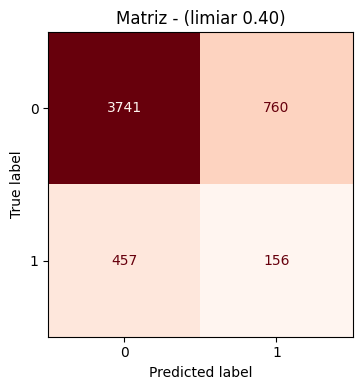

Resumo (teste):
- Limiar adotado: 0.40
- Precision atraso: 0.1703
- Recall atraso: 0.2545
- F2 atraso: 0.2316
- ROC-AUC atraso: 0.5945
- R2 atraso: -0.3277


In [5]:
# Celula 5: treino final do modelo com os melhores hiperparametros + avaliacao no teste.
sample_weight_v2 = np.where(y_train.values == 0, w0, 1.0)

model_v2 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=4242,
    n_jobs=-1,
    **best_params_v2,
)
model_v2.fit(X_train, y_train, sample_weight=sample_weight_v2)

# Converte saida do modelo para probabilidade de atraso (classe 0).
y_proba_class1_v2_train = model_v2.predict_proba(X_train)[:, 1]
y_proba_class1_v2_test = model_v2.predict_proba(X_test)[:, 1]
y_proba_atraso_v2_train = 1.0 - y_proba_class1_v2_train
y_proba_atraso_v2_test = 1.0 - y_proba_class1_v2_test

# Mantem o limiar escolhido para atraso e converte a decisao equivalente para a classe 1.
threshold_class1_v2 = 1.0 - best_threshold_v2
y_pred_class1_v2_train = (y_proba_class1_v2_train >= threshold_class1_v2).astype(int)
y_pred_class1_v2_test = (y_proba_class1_v2_test >= threshold_class1_v2).astype(int)
y_pred_atraso_v2_train = (y_proba_atraso_v2_train >= best_threshold_v2).astype(int)
y_pred_atraso_v2_test = (y_proba_atraso_v2_test >= best_threshold_v2).astype(int)

res_v2_train = metricas_atraso(y_train, y_pred_atraso_v2_train, y_proba_atraso_v2_train)
res_v2_test = metricas_atraso(y_test, y_pred_atraso_v2_test, y_proba_atraso_v2_test)
metricas_treino_v2 = metricas_gerais(y_train, y_pred_class1_v2_train, y_proba_class1_v2_train)
metricas_teste_v2 = metricas_gerais(y_test, y_pred_class1_v2_test, y_proba_class1_v2_test)

print("Metricas no teste (foco em atraso):")
display(pd.DataFrame(pd.Series(res_v2_test, name="Teste")).round(4))

# Explicacao breve das metricas para leitura dos resultados.
print("\nComo interpretar as metricas:")
print("- precision_atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.")
print("- recall_atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.")
print("- f1_atraso: media harmonica entre precision e recall (equilibrio entre os dois).")
print("- f2_atraso: semelhante ao F1, mas dando mais peso ao recall (bom para nao perder atrasos).")
print("- roc_auc_atraso: capacidade de separar atraso vs nao atraso em todos os limiares (quanto maior, melhor).")
print("- pr_auc_atraso: qualidade do modelo no trade-off precision x recall para classe rara (atraso).")

# Exibe matriz de confusao para visualizar erros da V2 no teste.
y_true_atraso_test = (y_test == 0).astype(int)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_true_atraso_test, y_pred_atraso_v2_test, cmap="Reds", ax=ax, colorbar=False
)
ax.set_title(f"Matriz - (limiar {best_threshold_v2:.2f})")
plt.tight_layout()
plt.show()

print("Resumo (teste):")
print(f"- Limiar adotado: {best_threshold_v2:.2f}")
print(f"- Precision atraso: {res_v2_test['precision_atraso']:.4f}")
print(f"- Recall atraso: {res_v2_test['recall_atraso']:.4f}")
print(f"- F2 atraso: {res_v2_test['f2_atraso']:.4f}")
print(f"- ROC-AUC atraso: {res_v2_test['roc_auc_atraso']:.4f}")
print(f"- R2 atraso: {res_v2_test['r2_atraso']:.4f}")

In [6]:
# Celula 6: resumo completo do modelo (metricas gerais e metricas de atraso).
print("=" * 120)
print("RESUMO COMPLETO DAS METRICAS DO XGBOOST")
print("=" * 120)

# ============================================================================
# METRICAS GERAIS
# ============================================================================
print("\nMETRICAS GERAIS")
print("(Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC, Balanced Accuracy, MCC, Brier Score, Log Loss)")

print("\n" + "─" * 120)
print("TREINO")
print("─" * 120)
df_v2_train_geral = pd.DataFrame(pd.Series(metricas_treino_v2, name="Treino"))
display(df_v2_train_geral.round(4))

print("\n" + "─" * 120)
print("TESTE")
print("─" * 120)
df_v2_test_geral = pd.DataFrame(pd.Series(metricas_teste_v2, name="Teste"))
display(df_v2_test_geral.round(4))

# ============================================================================
# METRICAS DE ATRASO (CLASSE 0)
# ============================================================================
print("METRICAS DE ATRASO (CLASSE 0)")
print("(Accuracy, Precision, Recall, F1, F2, ROC-AUC, PR-AUC, Balanced Accuracy, MCC, Brier Score, Log Loss)")

print("\n" + "─" * 120)
print("TREINO (ATRASO)")
print("─" * 120)
df_v2_train_atraso = pd.DataFrame(pd.Series(res_v2_train, name="Treino"))
display(df_v2_train_atraso.round(4))

print("\n" + "─" * 120)
print("TESTE (ATRASO)")
print("─" * 120)
df_v2_test_atraso = pd.DataFrame(pd.Series(res_v2_test, name="Teste"))
display(df_v2_test_atraso.round(4))

# ============================================================================
# RESUMO
# ============================================================================
print("RESUMO\n")
print("─" * 120 + "\n")
print(f"  Limiar utilizado: {best_threshold_v2:.2f}")
print(
    f"  Treino - Accuracy: {metricas_treino_v2['Accuracy']:.4f}, ROC-AUC: {metricas_treino_v2['ROC-AUC']:.4f}, R2: {metricas_treino_v2['R2']:.4f}, "
    f"Precision (Atraso): {res_v2_train['precision_atraso']:.4f}, Recall (Atraso): {res_v2_train['recall_atraso']:.4f}"
)
print(
    f"  Teste  - Accuracy: {metricas_teste_v2['Accuracy']:.4f}, ROC-AUC: {metricas_teste_v2['ROC-AUC']:.4f}, R2: {metricas_teste_v2['R2']:.4f}, "
    f"Precision (Atraso): {res_v2_test['precision_atraso']:.4f}, Recall (Atraso): {res_v2_test['recall_atraso']:.4f}"
)

RESUMO COMPLETO DAS METRICAS DO XGBOOST

METRICAS GERAIS
(Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC, Balanced Accuracy, MCC, Brier Score, Log Loss)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TREINO
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,Treino
Accuracy,0.4988
Precision,0.9900
Recall,0.4775
F1-score,0.6442
ROC-AUC,0.8047
PR-AUC,0.9862
R2,-3.0723
Balanced Accuracy,0.6924
MCC,0.1678
Brier Score,0.1921



────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TESTE
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,Teste
Accuracy,0.7620
Precision,0.8911
Recall,0.8311
F1-score,0.8601
ROC-AUC,0.5945
PR-AUC,0.9120
R2,-0.3277
Balanced Accuracy,0.5428
MCC,0.0725
Brier Score,0.1401


METRICAS DE ATRASO (CLASSE 0)
(Accuracy, Precision, Recall, F1, F2, ROC-AUC, PR-AUC, Balanced Accuracy, MCC, Brier Score, Log Loss)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TREINO (ATRASO)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,Treino
accuracy_atraso,0.4988
precision_atraso,0.0832
recall_atraso,0.9074
f1_atraso,0.1524
f2_atraso,0.3043
roc_auc_atraso,0.8047
pr_auc_atraso,0.2243
r2_atraso,-3.0723
balanced_accuracy_atraso,0.6924
mcc_atraso,0.1678



────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TESTE (ATRASO)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,Teste
accuracy_atraso,0.7620
precision_atraso,0.1703
recall_atraso,0.2545
f1_atraso,0.2041
f2_atraso,0.2316
roc_auc_atraso,0.5945
pr_auc_atraso,0.1679
r2_atraso,-0.3277
balanced_accuracy_atraso,0.5428
mcc_atraso,0.0725


RESUMO

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

  Limiar utilizado: 0.40
  Treino - Accuracy: 0.4988, ROC-AUC: 0.8047, R2: -3.0723, Precision (Atraso): 0.0832, Recall (Atraso): 0.9074
  Teste  - Accuracy: 0.7620, ROC-AUC: 0.5945, R2: -0.3277, Precision (Atraso): 0.1703, Recall (Atraso): 0.2545
